## Assignment 2

### GitHub Link

https://github.com/nodokak1/DSA4262

The Jupyter Notebook is under: Assignment_2/Assignment2.ipynb

### Running the code

#### Prerequisites
- Install **Docker Desktop** (Windows/Mac) or Docker Engine (Linux).
- Ensure Docker is running before proceeding.

#### Steps
1. Navigate to the Assignment Folder.
    - Open a terminal (PowerShell on Windows) and navigate to the ```Assignment_2```.

        ```
        cd Assignment_2
        ```

2. Build the Docker Image
    - Run the following command to build the Docker image:

        ```
        docker build -t dsa4262-a2 .
        ```
    - This may take several minutes on the first build.

3. Run the Docker Container
    - Start the container with:

        ```
        docker run -p 8888:8888 dsa4262-a2
        ```

4. Open Jupyter Notebook
    - After running the container, a URL similar to the following will appear in the terminal:

        ```
        http://127.0.0.1:8888/?token=xxxxxxxx
        ```
    Copy and paste this link into your browser.
    - Open:

        ```
        Assignment2.ipynb
        ```
    - Run all cells to reproduce the results by clicking the button:

        <img src="data/Screenshot%202026-02-25%20at%2018.54.38.png" width="400">

- If port 8888 is already in use
    - Run the container on a different port, for example:

        ```
        docker run -p 8889:8888 dsa4262-a2
        ```
    - Then open the printed link using port that you have used (e.g.: ```8889```).


### Libraries

In [ ]:
# Run from this cell and below.
import os
import sys
import random
import re
import gc
# Workaround for SHAP + numba on newer Python/NumPy builds.
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
# Keep Matplotlib config writable in notebook environments.
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".mplconfig"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import torch
import shap
from lime.lime_text import LimeTextExplainer


c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

### Importing Dataset

In [3]:
# dataset = load_dataset("andreagasparini/dreaddit")

# train_df = pd.DataFrame(dataset["train"])
# test_df = pd.DataFrame(dataset["test"])

# print(train_df.shape, test_df.shape)
# display(train_df.head())

# train_df.to_csv("data/dreaddit_train.csv", index=False)
# test_df.to_csv("data/dreaddit_test.csv", index=False)

# print("Saved locally to /data folder.")

In [4]:
train_df = pd.read_csv("data/dreaddit_train.csv")
test_df = pd.read_csv("data/dreaddit_test.csv")

In [5]:
print(train_df.columns)
print(train_df.info())
print(train_df['label'].value_counts())
print(train_df['label'].value_counts(normalize=True))

Index(['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='object', length=116)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Columns: 116 entries, subreddit to sentiment
dtypes: float64(106), int64(6), object(4)
memory usage: 2.5+ MB
None
label
1    1488
0    1350
Name: count, dtype: int64
label
1    0.524313
0    0.475687
Name: proportion, dtype: float64


From this, we can see that there are 2,838 training samples in the Dreaddit dataset. In addition, there is a relatively balanced dataset of label 1 for stressed (52%) and label 0 for non-stressed (48%).

### General EDA

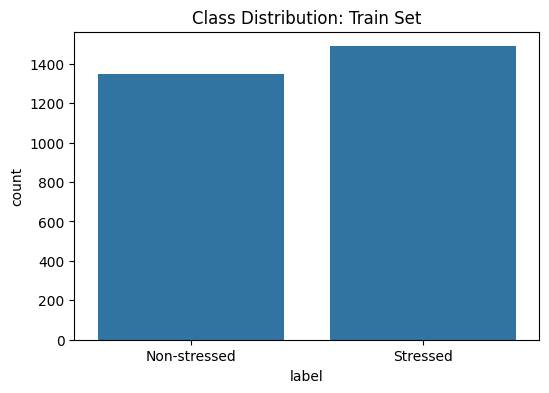

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train_df)
plt.title("Class Distribution: Train Set")
plt.xticks([0,1], ["Non-stressed", "Stressed"])
plt.show()

The previous statement is supported by the graph above, where the distribution of labels in the training set looks relatively even.

,count,stress_rate
subreddit,,
assistance,289,0.363322
homeless,168,0.375000
food_pantry,37,0.378378
relationships,552,0.447464
survivorsofabuse,245,0.457143
stress,64,0.546875
ptsd,584,0.568493
almosthomeless,80,0.587500
domesticviolence,316,0.639241


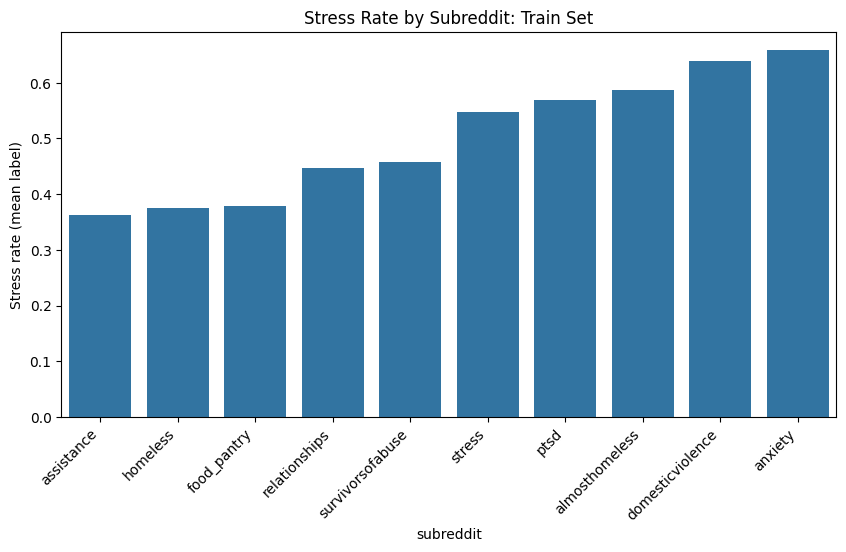

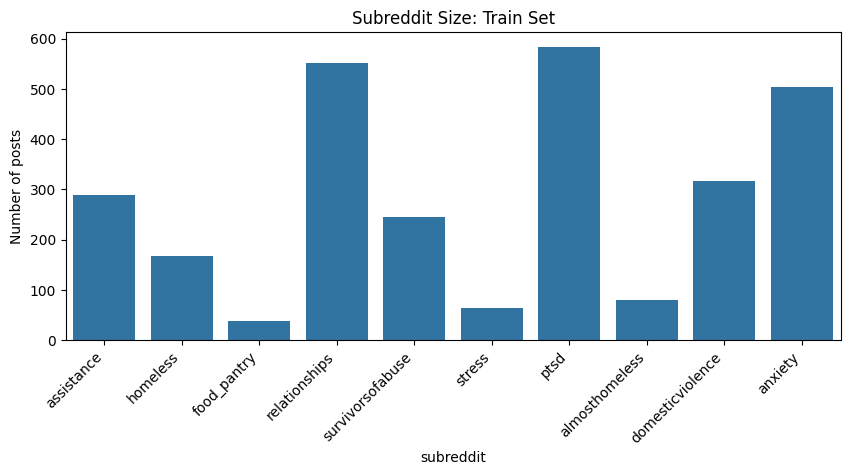

In [7]:
sub_stats = (train_df.groupby("subreddit")["label"]
             .agg(count="count", stress_rate="mean")
             .sort_values("stress_rate"))
display(sub_stats)

plt.figure(figsize=(10,5))
sns.barplot(x=sub_stats.index, y=sub_stats["stress_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Stress rate (mean label)")
plt.title("Stress Rate by Subreddit: Train Set")
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=sub_stats.index, y=sub_stats["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of posts")
plt.title("Subreddit Size: Train Set")
plt.show()


Here, *Stress Rate* is defined by the number of posts from each label divided by the total number of posts.

From these diagrams, it can be observed that stress is not uniformly distributed across subreddits. It can be observed that subreddits on topics like anxiety, domestic violence, and almost homeless has high stress rates even though the number of posts may sometimes be less than the subreddits with lower stress rates. This suggests that the classification performance may be related to the topic of the subreddit. This may mean that it may be hard to generalise the model, since it may rely on subreddit-specific lexical patterns instead of signals of stress in text.

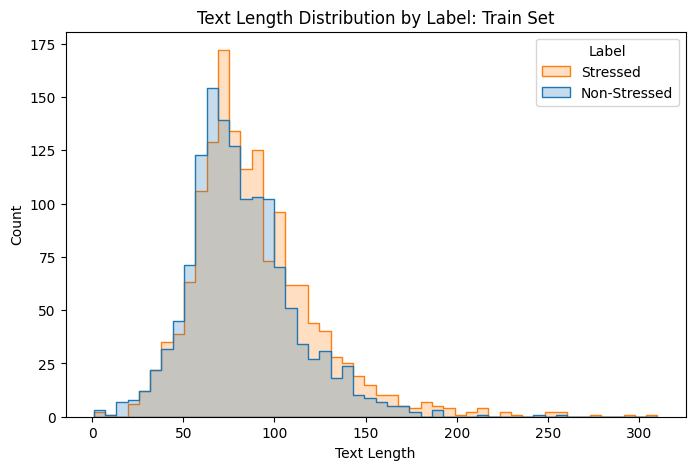

In [8]:
train_df["text_length"] = train_df["text"].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x="text_length", hue="label", bins=50, element="step")
plt.title("Text Length Distribution by Label: Train Set")
plt.xlabel("Text Length")
plt.legend(title="Label", labels=["Stressed", "Non-Stressed"])
plt.show()

In general, a high overlap between the distribution of text length of the two labels can be observed, where there is a peak around 60 - 90 words. This indicates that the length of the text alone cannot properly determine the correct label to be assigned to the Reddit post.

However, it can be seen that the distribution of the Reddit posts labelled as "Stressed" has a longer right tail. This could potentially be due to the posts labelled as "Stressed" having longer elaboration, and of people trying to explain their situations.

Overall, it can be seen that text length alone is insufficient as a determinant of whether the post should be classified as "Stressed" or not. 

### Model Building

#### Baseline Model


TF-IDF representations combined with Logistic Regression is used for the baseline model.



**TF-IDF** (Term Frequency-Inverse Document Frequency) transforms raw text into a sparse numerical representation that highlights words and short phrases that are informative within the corpus. In the context of stress detection, linguistic signals often manifest as key words (e.g., "overwhelmed", "panic") or short phrases (e.g., "can't cope", "don't know what to do"). Including both unigrams and bigrams allows the model to capture these stress-related lexical patterns without relying on deep contextual embeddings.



**Logistic Regression** is selected as a linear classifier that performs well on high-dimensional sparse text data. Given the rather small dataset size, a linear model reduces the risk of overfitting compared to more complex neural architectures. Additionally, logistic regression provides direct interpretability via feature coefficients, which is important given the clinical implications of stress detection.



Stratified 5-fold cross-validation is used to preserve class proportions across folds and provide a robust estimate of generalisation performance. This reduces the risk of overfitting to the training set.



F1-score is used as the evaluation metric, as it balances precision and recall and is more appropriate than accuracy in settings where false negatives (missed stress signals) may carry higher real-world cost.



Class weighting (```class_weight="balanced"```) is applied to mitigate the slight class imbalance.



A small grid search is conducted over vocabulary size, n-gram range, and regularisation strength to fairly optimise the model modestly.


In [9]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1,1), max_features=20000)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

baseline_model.fit(train_df["text"], train_df["label"])
pred_base = baseline_model.predict(test_df["text"])
print("Baseline Test F1:", f1_score(test_df["label"], pred_base))


Baseline Test F1: 0.7204301075268817


The F1-score of **0.7204** indicates a fairly good performance of the baseline model. However, further refinements and exploration can be done to the finetuned model to improve its performance further.


#### Finetuned Model


In [10]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_features": [20000, 50000],
    "tfidf__min_df": [1, 2, 5],
    "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=1, verbose=1)
grid.fit(train_df["text"], train_df["label"])

print("Tuned CV F1:", grid.best_score_)
print("Best params:", grid.best_params_)

tuned_model = grid.best_estimator_
pred_tuned = tuned_model.predict(test_df["text"])
print("Tuned Test F1:", f1_score(test_df["label"], pred_tuned))


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Tuned CV F1: 0.765046770304467
Best params: {'clf__C': 2.0, 'tfidf__max_features': 50000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Tuned Test F1: 0.7512315270935961


From the results, it can be observed that the use of bigrams (```'tfidf__ngram_range': (1,2)'```) helped to give better performance, which indicates that short phrases tend to carry more important contextual information compared to single words alone. The ```tdidf__max_features``` having a high value of 50000 shows that the model benefitted from having a larger vocabulary size compared to a more limited vocabulary. The relatively high regularisation parameter (```C = 4.0```) implies that stronger regularisation was not necessary, indicating that the dataset provides sufficient signal to support a richer feature space without severe overfitting.



When evaluated on the test set, the model achieved an F1 score of **0.7346**. However, this shows a small drop from the F1 score on the training set, which was **0.7673**. This indicates a mild overfitting but overall stable generalisation. This indicates that lexical patterns alone provide substantial predictive signal, though performance is not perfect.


### BERT Model


While the tuned logistic regression model demonstrates strong performance using lexical features alone, it relies primarily on surface-level n-gram representations. To investigate whether deeper contextual semantics can further improve stress detection, we next fine-tune a pretrained transformer model (DistilBERT).


To create a validation set for fine-tuning BERT, an 80/20 split of the training dataset is done. This splits the training dataset further into 80% of the training set into the training dataset and 20% into the validation dataset.


In [11]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

train_split_df = train_df.iloc[train_idx].reset_index(drop=True)
val_split_df   = train_df.iloc[val_idx].reset_index(drop=True)


Unlike TF-IDF representations, transformer-based models require tokenised inputs that are compatible with their pretrained vocabulary. Therefore, a pretrained tokenizer (```distilbert-base-uncased```) is used.


In [12]:
bert_name = "distilbert-base-uncased" 
tokenizer = AutoTokenizer.from_pretrained(bert_name)

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = TextDataset(
    train_split_df["text"],
    train_split_df["label"],
    tokenizer
)

val_dataset = TextDataset(
    val_split_df["text"],
    val_split_df["label"],
    tokenizer
)

test_dataset = TextDataset(
    test_df["text"],
    test_df["label"],
    tokenizer
)

Next, the DistilBERT model is fine-tuned. The pretrained transformer provides contextual embeddings, while a randomly initialised classification head is added for the stress detection task.



The following hyperparameters are set:



- **Learning rate** (```learning_rate=2e-5```): controls the magnitude of parameter updates during gradient descent.

- **Batch size** (```per_device_train_batch_size=16```, ```per_device_eval_batch_size=32```): determines how many samples are processed before updating model parameters.

- **Epoch** (```num_train_epochs=3```): specifies how many full passes are made over the training data.

- **Weight decay** (```weight_decay=0.01```): adds L2 regularisation to model parameters during optimisation.

- **Evaluation strategy** (```eval_strategy="epoch"```): determines how frequently validation performance is measured.

- **Metric for model selection** (```metric_for_best_model="f1"```): F1-score is used as the primary selection metric because it balances precision and recall.

- **Load best model at the end** (```load_best_model_at_end = True```): ensures that after training completes, the model checkpoint with the highest validation F1-score is retained.


In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"f1": f1_score(labels, preds)}

model = AutoModelForSequenceClassification.from_pretrained(
    bert_name,
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=42,
    report_to="none"
)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 177.31it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Now, the DistilBERT model is trained using the training arguments defined in the previous code block.



This trainer has the following configurations:

- **Training dataset** (```train_dataset=train_hf```): the 80% training split used to update model weights.



- **Validation dataset** (```eval_dataset=val_hf```): the 20% validation split used to monitor generalisation performance after each epoch.



- **Tokenizer** (```tokenizer=tokenizer```): ensures inputs are converted into token IDs and attention masks consistent with the pretrained model vocabulary.



- **Custom evaluation function** (``` compute_metrics=compute_metrics```): computes F1-score from model logits, aligning model selection with the assignment's primary metric.


In [14]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

train_out = trainer.predict(train_dataset)
val_out   = trainer.predict(val_dataset)
test_out  = trainer.predict(test_dataset)

print("Train F1:", compute_metrics((train_out.predictions, train_out.label_ids))["f1"])
print("Val F1:",   compute_metrics((val_out.predictions,   val_out.label_ids))["f1"])
print("Test F1:",  compute_metrics((test_out.predictions,  test_out.label_ids))["f1"])

c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,No log,0.402260,0.827350
2,No log,0.412753,0.824138
3,No log,0.476552,0.829508


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]
c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.11it/s]
c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.28it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gam

c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train F1: 0.9526943644590703
Val F1: 0.8295081967213115
Test F1: 0.8244274809160306


In [15]:
train_texts = set(train_split_df["text"].astype(str))
val_dupes = val_split_df["text"].astype(str).isin(train_texts).mean()
test_dupes = test_df["text"].astype(str).isin(train_texts).mean()

print("Val dup rate:", val_dupes)
print("Test dup rate:", test_dupes)

Val dup rate: 0.01232394366197183
Test dup rate: 0.002797202797202797


The fine-tuned DistilBERT model achieved:

- **Train F1:** 0.9527
- **Validation F1:** 0.895
- **Test F1:** 0.8244

This shows strong learning of stress-related language patterns, with a clear drop from train to validation/test, indicating some overfitting. Because there is also a jump between the validation and test F1, the overfitting issue is rather prevalent. To ensure that this overfitting is not due to data leakage, a check of the number of duplicates is done. Since the number of duplicates are close to 0, the issue of overfitting does not stem from data leakage.

### Model Comparison
This table compares all three models on the same test set. The primary selection criterion is **Test F1-score**.


In [16]:
# Collect BERT test predictions to compute the same metrics as classical models
bert_test_logits = trainer.predict(test_dataset).predictions
bert_test_pred = np.argmax(bert_test_logits, axis=1)
y_test = test_df["label"].values

results = pd.DataFrame([
    {
        "Model": "Baseline TF-IDF + Logistic Regression",
        "Accuracy": accuracy_score(y_test, pred_base),
        "Precision": precision_score(y_test, pred_base),
        "Recall": recall_score(y_test, pred_base),
        "F1": f1_score(y_test, pred_base),
    },
    {
        "Model": "Tuned TF-IDF + Logistic Regression",
        "Accuracy": accuracy_score(y_test, pred_tuned),
        "Precision": precision_score(y_test, pred_tuned),
        "Recall": recall_score(y_test, pred_tuned),
        "F1": f1_score(y_test, pred_tuned),
    },
    {
        "Model": "DistilBERT",
        "Accuracy": accuracy_score(y_test, bert_test_pred),
        "Precision": precision_score(y_test, bert_test_pred),
        "Recall": recall_score(y_test, bert_test_pred),
        "F1": f1_score(y_test, bert_test_pred),
    }
]).sort_values("F1", ascending=False)

display(results.round(4))

best_model = results.iloc[0]
print(f"Best model by Test F1: {best_model['Model']} (F1={best_model['F1']:.4f})")


c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,Model,Accuracy,Precision,Recall,F1
2,DistilBERT,0.8070,0.7770,0.8780,0.8244
1,Tuned TF-IDF + Logistic Regression,0.7175,0.6885,0.8266,0.7512
0,Baseline TF-IDF + Logistic Regression,0.7091,0.7147,0.7263,0.7204


Best model by Test F1: DistilBERT (F1=0.8244)


From the table above, **DistilBERT** achieved the best overall performance on the Dreaddit test set, with the highest F1-score, outperforming both TF-IDF + Logistic Regression variants.

- Baseline TF-IDF + Logistic Regression provides a useful lower bound and is easy to interpret.
- Tuned TF-IDF + Logistic Regression improves over baseline, showing that n-grams and regularization tuning help.
- DistilBERT performs best, suggesting contextual semantics are important for stress detection beyond surface lexical cues.

As such, **DistilBERT** will be chosen as the best model after finetuning and exploring a veriety of methods. However, the fact that logistic regression is more interpretable cannot be ignored. Although DistilBERT has the best predictive performance, it is more computationally expensive and less directly interpretable than Logistic Regression.  

#### DistilBERT Error Analysis

c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,Accuracy,Precision,Recall,F1
DistilBERT Test,0.807,0.777,0.878,0.8244



Classification Report (DistilBERT on Test Set):
              precision    recall  f1-score   support

Non-stressed       0.85      0.73      0.79       346
    Stressed       0.78      0.88      0.82       369

    accuracy                           0.81       715
   macro avg       0.81      0.80      0.81       715
weighted avg       0.81      0.81      0.81       715



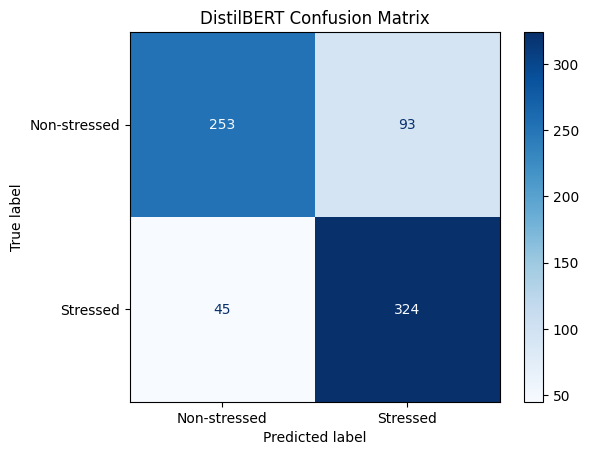

In [17]:
# Get DistilBERT test predictions and probabilities
bert_test_output = trainer.predict(test_dataset)
bert_test_logits = bert_test_output.predictions
bert_test_pred = np.argmax(bert_test_logits, axis=1)
y_test = test_df["label"].values

# Convert logits to probabilities for confidence analysis
exp_logits = np.exp(bert_test_logits - np.max(bert_test_logits, axis=1, keepdims=True))
bert_test_proba = exp_logits / exp_logits.sum(axis=1, keepdims=True)
bert_test_conf = bert_test_proba.max(axis=1)

bert_metrics = {
    "Accuracy": accuracy_score(y_test, bert_test_pred),
    "Precision": precision_score(y_test, bert_test_pred),
    "Recall": recall_score(y_test, bert_test_pred),
    "F1": f1_score(y_test, bert_test_pred),
}

display(pd.DataFrame([bert_metrics], index=["DistilBERT Test"]).round(4))
print("\nClassification Report (DistilBERT on Test Set):")
print(classification_report(y_test, bert_test_pred, target_names=["Non-stressed", "Stressed"]))

cm = confusion_matrix(y_test, bert_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-stressed", "Stressed"])
disp.plot(cmap="Blues", values_format="d")
plt.title("DistilBERT Confusion Matrix")
plt.show()


The fine-tuned DistilBERT model achieved strong and balanced performance:

- **Accuracy**: 0.8-0.81
- **F1**: 0.82

Here, *true positives* are Stressed posts predicted correctly, and *true negatives* are Non-stressed posts predicted correctly. Thus, *false positives* are defined as Non-stressed predicted as Stressed. Conversely, *false negatives* are defined as Stressed predicted as Non-stressed. 

From the confusion matrix:
- **True negatives**: 253
- **False positives**: 93
- **False negatives**: 45
- **True positives**: 324

These results show that the model performs similarly across both classes, with precision and recall around 0.80-0.87. This is desirable for stress detection because it avoids heavily favoring one class over the other.

The model makes less false negatives (45) than false positives (93). This means some stressed posts are still missed, which is important in a mental health setting where missed cases may be more costly than extra alerts. However, it still makes more false positives which is better in this case to err on the side of caution.

Overall, DistilBERT demonstrates good generalisation and a balanced precision-recall profile, but it still struggles with ambiguous or subtle stress expressions.


### Interpretability

In [18]:
# Recreate evaluation dataframe
bert_test_output = trainer.predict(test_dataset)
bert_test_logits = bert_test_output.predictions
bert_test_pred = np.argmax(bert_test_logits, axis=1)

exp_logits = np.exp(bert_test_logits - np.max(bert_test_logits, axis=1, keepdims=True))
bert_test_proba = exp_logits / exp_logits.sum(axis=1, keepdims=True)
bert_test_conf = bert_test_proba.max(axis=1)

bert_eval_df = test_df[["subreddit", "text", "label"]].copy()
bert_eval_df["pred"] = bert_test_pred
bert_eval_df["confidence"] = bert_test_conf
bert_eval_df["error_type"] = np.where(
    (bert_eval_df["label"] == 1) & (bert_eval_df["pred"] == 0),
    "False Negative",
    np.where(
        (bert_eval_df["label"] == 0) & (bert_eval_df["pred"] == 1),
        "False Positive",
        "Correct"
    )
)

bert_eval_df.head()


c:\Users\206910279\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,subreddit,text,label,pred,confidence,error_type
0,relationships,"Its like that, if you want or not.“ ME: I have...",0,0,0.972697,Correct
1,anxiety,I man the front desk and my title is HR Custom...,0,0,0.931900,Correct
2,ptsd,We'd be saving so much money with this new hou...,1,1,0.968946,Correct
3,ptsd,"My ex used to shoot back with ""Do you want me ...",1,1,0.966111,Correct
4,relationships,I haven’t said anything to him yet because I’m...,0,1,0.952358,False Positive


In [19]:
err = bert_eval_df[bert_eval_df["error_type"] != "Correct"].copy()

fp_text = err[err["error_type"]=="False Positive"].sort_values("confidence", ascending=False).iloc[0]["text"]
fn_text = err[err["error_type"]=="False Negative"].sort_values("confidence", ascending=False).iloc[0]["text"]

print("FP example:\n", fp_text[:400], "\n")
print("FN example:\n", fn_text[:400], "\n")

FP example:
 I feel like I am just being written off because of my diagnosis before anyone even tries to look into it and see if anything else might be at play. I'd just as soon not say anything about my PTSD to be taken seriously, but it appears in my medical records. Or when I list my medications as required, Drs usually ask me what the meds are treating and it comes up then. Has anyone else had this experie 

FN example:
 He is our little angel and we are both gaga for him, but money has been extraordinary tight, adjusting to parent life and sleep deprivation has been tough for both of us. We were fighting and bickering a bit for the first time in his first months of life, but I figured that was normal for new parents. I work in the financial industry for a modest income (working hard currently to get to the next l 



In [20]:
trainer.model.eval()
trainer.model.to("cpu")

# SHAP masker for text
masker = shap.maskers.Text(tokenizer)

def predict_proba_shap(texts):
    texts = [str(t) for t in texts]
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    with torch.no_grad():
        outputs = trainer.model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    return probs

# This is the missing object
shap_explainer = shap.Explainer(
    predict_proba_shap,
    masker,
    output_names=["Non-stressed", "Stressed"]
)

PartitionExplainer explainer: 2it [00:16, 16.74s/it]               


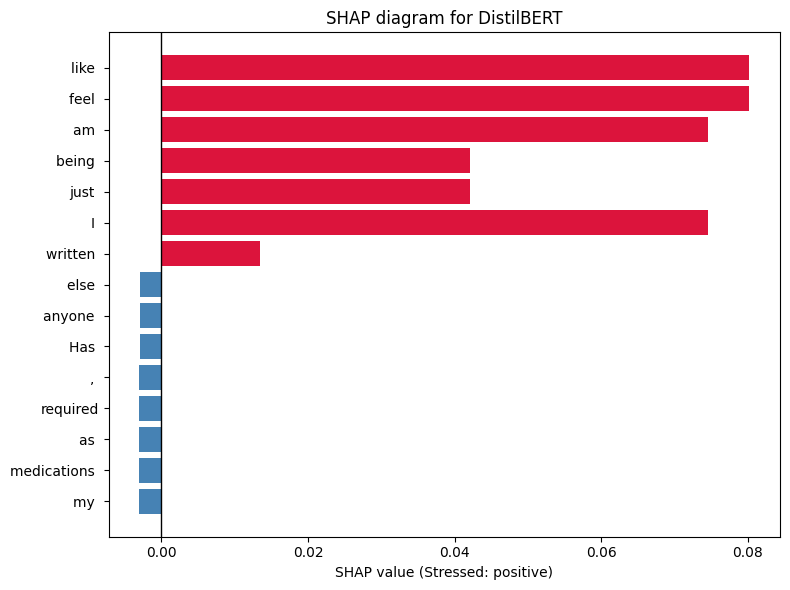

In [21]:
# small sample
sample_text = fp_text

# compute shap
sv = shap_explainer([sample_text], max_evals=160)[0, :, 1]  # class 1 = Stressed

# merge subword tokens (##...) and build clean table
tokens = list(sv.data)
values = np.array(sv.values, dtype=float)

merged_tokens, merged_vals = [], []
for t, v in zip(tokens, values):
    t = str(t)
    if t in ["[CLS]", "[SEP]", "[PAD]"] or t.strip() == "":
        continue
    if t.startswith("##") and merged_tokens:
        merged_tokens[-1] += t[2:]
        merged_vals[-1] += v
    else:
        merged_tokens.append(t)
        merged_vals.append(v)

shap_df = pd.DataFrame({"token": merged_tokens, "shap": merged_vals})

# lot only top contributors
top = pd.concat([
    shap_df.nsmallest(8, "shap"),
    shap_df.nlargest(8, "shap")
]).sort_values("shap")

plt.figure(figsize=(8, 6))
colors = np.where(top["shap"] > 0, "crimson", "steelblue")
plt.barh(top["token"], top["shap"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("SHAP diagram for DistilBERT")
plt.xlabel("SHAP value (Stressed: positive)")
plt.tight_layout()
plt.show()


This SHAP plot explains one DistilBERT prediction for the **Stressed** class.

- **Red bars (positive SHAP)** push the prediction toward **Stressed**.
- **Blue bars (negative SHAP)** push the prediction toward **Non-stressed**.
- The farther a bar is from zero, the stronger that token’s influence on this specific prediction.

Overall, the model appears to rely on emotionally loaded or conflict-related language as stress signals, while neutral/contextual terms pull the prediction downward.Some tokens are tokenization artifacts, so SHAP is interpreted as approximate local evidence rather than causal proof.

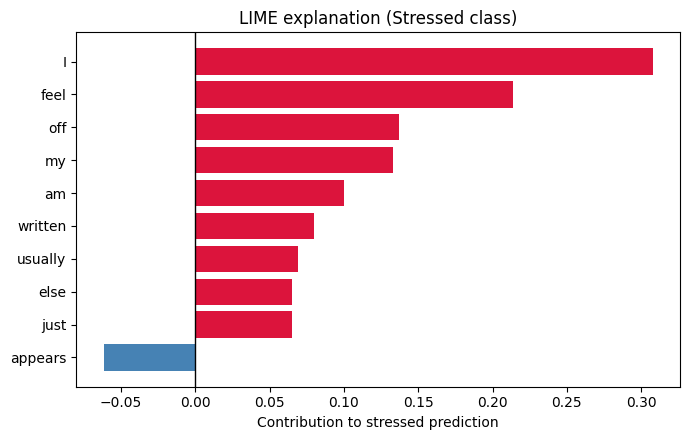

In [22]:
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

lime_device = torch.device("cpu")
trainer.model.to(lime_device)
trainer.model.eval()

def predict_proba_lime(texts, batch_size=16, max_len=256):
    probs_all = []
    texts = [str(t) for t in texts]

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_len
            )
            enc = {k: v.to(lime_device) for k, v in enc.items()}
            logits = trainer.model(**enc).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_all.append(probs)

    return np.vstack(probs_all)

explainer = LimeTextExplainer(class_names=["Non-stressed", "Stressed"])
text_for_lime = fp_text

exp = explainer.explain_instance(
    text_for_lime,
    predict_proba_lime,
    num_features=10,
    num_samples=400,
    labels=[1]
)

lime_df = pd.DataFrame(exp.as_list(label=1), columns=["token", "weight"])

plot_df = lime_df.sort_values("weight")
colors = np.where(plot_df["weight"] > 0, "crimson", "steelblue")

plt.figure(figsize=(7, 4.5))
plt.barh(plot_df["token"], plot_df["weight"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("LIME explanation (Stressed class)")
plt.xlabel("Contribution to stressed prediction")
plt.tight_layout()
plt.show()


LIME suggests the model’s stressed prediction is driven primarily by first-person self-disclosure language (“I”, “feel”, “my”) and a negative state descriptor (“appears”). This aligns with the intuition that stressed posts often involve personal accounts of feelings. However, the dominance of pronouns/function words indicates the model may be partially using writing style (first-person narration) rather than specific stress symptoms, which could lead to false positives for neutral personal stories. The single negative contributor (“list”) hints that informational/structured posts are less likely to be flagged as stressed.

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 351.10it/s, Materializing param=pre_classifier.weight]                                  


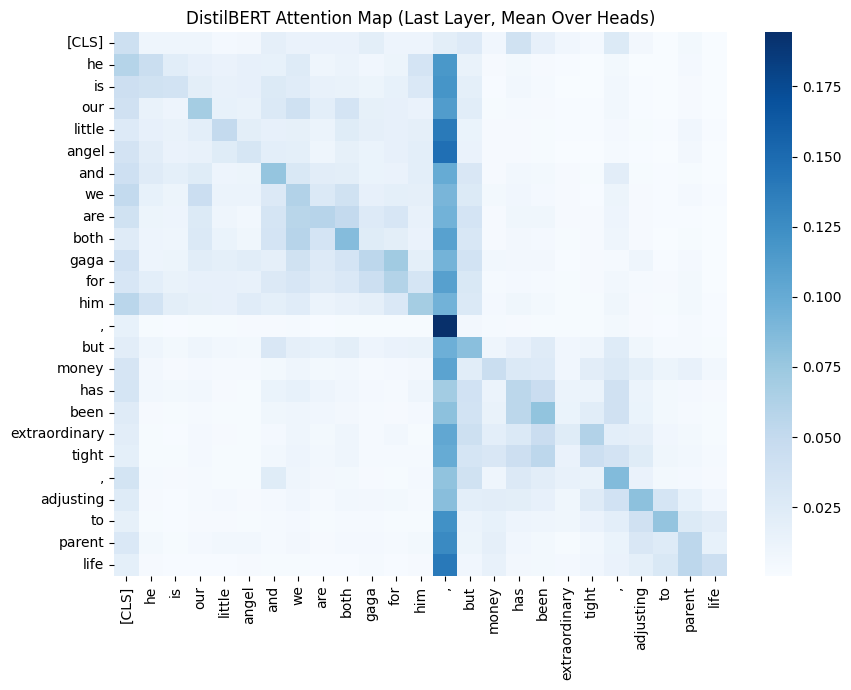

In [23]:
# 1) Pick one example text
if "bert_eval_df" in globals() and len(bert_eval_df) > 0:
    # choose a high-confidence wrong case if available
    err = bert_eval_df[bert_eval_df["error_type"] != "Correct"].sort_values("confidence", ascending=False)
    attn_text = err.iloc[0]["text"] if len(err) > 0 else test_df.iloc[0]["text"]
else:
    attn_text = test_df.iloc[0]["text"]

# 2) Forward pass with attentions
device = next(trainer.model.parameters()).device
best_ckpt = trainer.state.best_model_checkpoint or training_args.output_dir

# Reload same weights, but force eager attention so attentions are returned
attn_model = AutoModelForSequenceClassification.from_pretrained(
    best_ckpt,
    attn_implementation="eager",
    output_attentions=True
).to(device)
attn_model.eval()

enc = tokenizer(attn_text, return_tensors="pt", truncation=True, max_length=64)
enc = {k: v.to(device) for k, v in enc.items()}

with torch.no_grad():
    out = attn_model(**enc, output_attentions=True, return_dict=True)

if out.attentions is None or len(out.attentions) == 0:
    raise RuntimeError("No attentions returned. Check transformers/torch backend.")

attn_last = out.attentions[-1][0].mean(dim=0).cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])

n = min(25, len(tokens))
plt.figure(figsize=(9, 7))
sns.heatmap(attn_last[:n, :n], cmap="Blues", xticklabels=tokens[:n], yticklabels=tokens[:n])
plt.xticks(rotation=90)
plt.title("DistilBERT Attention Map (Last Layer, Mean Over Heads)")
plt.tight_layout()
plt.show()



The attention heatmap visualises how tokens attend to one another in the final DistilBERT layer. Darker cells indicate stronger attention weights. In this example, attention is concentrated around self-referential and affective tokens (e.g.: “I”, “feel”, “am”, “like”, “my”), rather than being uniformly distributed across all words.

The CLS-to-token plot further shows which tokens the model’s sentence-level representation focuses on most before classification. Higher attention to terms related to personal state and internal experience suggests the model is using psychologically meaningful cues when predicting stress.

Overall, the attention patterns are consistent with the SHAP/LIME findings: the prediction is influenced more by emotionally and personally salient language than by neutral function words. However, attention is not a causal explanation on its own, so it is interpreted as supporting evidence alongside SHAP and LIME.

### Analysis 1-3: Error Analysis

#### Analysis 1: High Confidence Error Analysis

In [24]:
errors = bert_eval_df[bert_eval_df["error_type"] != "Correct"].copy()

fp = errors[errors["error_type"] == "False Positive"].sort_values("confidence", ascending=False)
fn = errors[errors["error_type"] == "False Negative"].sort_values("confidence", ascending=False)

print("Total errors:", len(errors))
print("False Positives:", len(fp))
print("False Negatives:", len(fn))

pd.set_option("display.max_colwidth", None)

print("\nTop False Positives:")
display(fp[["subreddit","confidence","text"]].head(10))
print("\nTop False Negatives:")
display(fn[["subreddit","confidence","text"]].head(10))


Total errors: 138
False Positives: 93
False Negatives: 45

Top False Positives:


,subreddit,confidence,text
241,ptsd,0.978665,"I feel like I am just being written off because of my diagnosis before anyone even tries to look into it and see if anything else might be at play. I'd just as soon not say anything about my PTSD to be taken seriously, but it appears in my medical records. Or when I list my medications as required, Drs usually ask me what the meds are treating and it comes up then. Has anyone else had this experience? What has worked for you to be taken seriously?"
542,homeless,0.978247,"The curfew at the shelter keeps me grounded and safe from myself. The rules and the structure with morning routine even though I've just felt it for one day, has already boosted me. I used to stay up until 2-3am, blowing all my money just binging and purging. Now I have to pause and ride out my emotions. I have to be in bed at 10pm."
216,survivorsofabuse,0.978065,"I sent a respectful email to my primary psychiatrist explaining my thoughts on how it was inappropriate to have Paterno's picture prominently displayed. Am I fucked up in the head for thinking this wrong? In the past, I had a mild traumatic brain injury. Sometimes I over react. 24 hours post appointment, I'm still bitter about the Paterno pics."
50,relationships,0.976630,"None of the issues we discuss get addressed. 6) After a while, I get really pissed, my significant other gets angry with me over some issue, and she ends up breaking up with me. I am weary of this whole emotional drama that I have to go through to end a relationship. I almost feel like it's not even my choice to end a relationship. Is there a way to avoid this whole process?"
242,relationships,0.976605,"I can't guarantee that I will never change my mind, but I've never dreamt of happily ever after, I don't really believe in eternal love and soulmates and all this stuff so I guess it's not really likely. I'm not asexual or aromantic, I love sex and I love him in a non-platonic way, I just can't compromise on that kind of thing, I wouldn't even know how to do it. I could meet his family, pretend to like them, pretend to bond with them and pretend to care, but that's really just lying to make him happy. I've tried it before and it makes me hating myself and them. I've always told him the the truth about the level of commitment I'm comfortable with, but nevertheless I feel like I'm leading him on."
269,ptsd,0.975973,He pretty much told me that he was angry and disappointed and would probably not forgive me for a while and that I owe him. I was going to go... I still want to. I just am looking at either going to this wedding and being evicted or not going and dealing with the disappointment. I don't feel like I have a choice.
543,homeless,0.975956,"Well, 18 years of being in and out of hospitals, treatment and addiction finally caught up to me. This is my first time homeless and it's scary but I'm grateful for the bright light that I've started to see. I don't abuse alcohol or drugs, but I'm no different than someone who does...I have other mental health issues that I feel nobody really can understand. It has essentially rendered me a useless piece of shit. I was engaging in unhealthy behaviors up to 10 hours a day, if not more."
598,homeless,0.973585,"Hey guys, circumstances in my life has brought me to being homeless starting tomorrow. I live in Central Florida and the reason why I come to this position is due to my car breaking down, not being able to make it to work since its a 35 mile commute, and now that I can't pay rent, I have to leave the room I'm renting. Lately though Ive been thinking a lot of leaving to New York. I'll be homeless there, yes, but at least I'll be able to get around with 24/7 transportation. My question is: Is this a good idea?"
205,ptsd,0.970917,If I am to survive I must defy him I'm leaving this behind I'll go so far away He'll never find me I know that I'm Making that the last time
314,relationships,0.970027,"I've been renting since university and I'm getting s


Top False Negatives:


,subreddit,confidence,text
174,relationships,0.981007,"He is our little angel and we are both gaga for him, but money has been extraordinary tight, adjusting to parent life and sleep deprivation has been tough for both of us. We were fighting and bickering a bit for the first time in his first months of life, but I figured that was normal for new parents. I work in the financial industry for a modest income (working hard currently to get to the next level where I'll make substantially more) and she works for an arts-based nonprofit. I have no particular attachment to the financial industry, it's just been a way to pay the bills and I find it interesting enough. She's a passionate artist though, always knew she wanted to be one, and it's really important to her."
615,survivorsofabuse,0.980671,"I'd like to note that I have had a couple close individuals look at my emails, evidence, etc since the last court date. I'm not that crazy, but I showed them the emails because I wanted to make sure they were real. The emails, evidence, and notes are all real. I checked my phone history, and the phone calls to the advocate and office are all logged and sufficient in length to indicate that an actual conversation occurred. I never doubted reality before the abuse, and I have never done so outside of the abuse."
173,relationships,0.978972,Maybe anyone with a history of abuse or trauma can tell me if there are particular things to be sensitive to here: I tried to be supportive but obviously failed in the end here. She's talking about wanting to divorce me. We're looking into couples therapy. I really appreciate any insight or advice. **TLDR**: Wife is working on an art piece that is important for her career in the arts non-profit world.
507,stress,0.978485,"We had 2 classes together, so we spent a few hours together most days working through problem sets. This next semester, I won't even have that. I'll probably be in more isolation this time around. Any tips are appreciated. Thanks!"
566,ptsd,0.977259,"I would like to reach out for help from someone supportive before an episode becomes too intense to ask for help. I would like to acknowledge the symptoms and temporary nature of the situation as to let it pass without causing additional damage. I finally realized that fighting my traumatic episodes is like a rigid oak tree trying to resist a flooding dam. Do any of you guys have ways to be ""okay"" with an episode? If so, how do you find the flexibility and patience to not fight against it?"
389,relationships,0.976909,"She told me that things had to go back to where we were before we ever went to the concert. I agreed, and stopped talking to her aside from professional responsibilities. NOW... in that period of time since two MAJOR things have happened. 1. Her mother was diagnosed with cancer."
239,ptsd,0.974340,"She's the first person I've ever really opened up to. I haven't told her everything about whats happened, but she does know about my anxiety (which I get from my PTSD) and she reacts sportively to it. To some extent, I let me be ""myself"" around her, whatever I am. She's moving. She's moving to Maryland."
175,relationships,0.973668,"We met about 2.5 years ago, both somewhat fresh off our respective divorces. I felt we had a real connection, we fell for each other hard, dated (eventually lived together) for a little less than a year before she got pregnant. We were both really happy as we had both talked about wanting children - at the time we got pregnant we were ""not NOT trying,"" we had definitely had many conversations and were both on board and happy to have a child together. We felt we had met our true love in each other. Things have been rough since the birth of our son."
420,domesticviolence,0.962503,"And yes, I would love help. I live in <location>. I can't use a phone as we only have one; house phone, that mom is always sitting near. I would love to be given links to sites that can help my brother and I to places that wil

It can be observed that a total of 138 errors were made by the model, with 93 false positives and 45 false negatives. This shows that the model is more likely to flag Stressed posts that are in fact Non-Stressed. This is the ideal situation in practice, as it will be better for safety, but may create unnecessary alerts and workload if a moderator is involved.

Here, top false negatives and top false positives are the errors made with the highest confidence. Listed below are some of the patterns observed from the top errors made:

1. **False positives**: The false positives made contain emotionally-intense (e.g.: "really pissed", "hating myself", "really angry", "useless") and trauma related (e.g.: "PTSD", "abuse", homelessness", "addiction", "drugs") language. Even though the post may contain parts that talk about how the person is in a better place now and coping with their situation, the language used makes the model flag out these posts as stressed when they are, in fact, not.

2. **False negatives**: The posts with false negatives tend to be more narrative-based, and tells a story. Because of this, the language used may not be as emotionally intense as those that are false positives. As such, they will not be flagged as posts that indicate stress even though the story-telling shows obvious signs of stress.

3. **Subreddits**: The subreddits where these errors are made are generally concentrated in those that are more trauma-related or person based. They are generally the few key subreddits: "ptsd", "stress", "relationships", "survivorsofabuse", "domeesticviolence". This could be due to the language used in the subreddits, as they could be more intense.

While is model is useful for flagging out posts, it should not be used autonomously. Because of the nature of the model where false positives are more likely, deployment should include human review and threshold tuning to balance alert burden vs missed cases.

#### Analysis 2: Subreddit Error Analysis

In [25]:
sub_err = (
    bert_eval_df.assign(is_error=(bert_eval_df["error_type"] != "Correct").astype(int))
    .groupby("subreddit")
    .agg(
        n=("label","size"),
        error_rate=("is_error","mean"),
        fp_rate=("error_type", lambda s: (s=="False Positive").mean()),
        fn_rate=("error_type", lambda s: (s=="False Negative").mean())
    )
    .sort_values("error_rate", ascending=False)
)
display(sub_err.round(3))


,n,error_rate,fp_rate,fn_rate
subreddit,,,,
relationships,142,0.275,0.176,0.099
domesticviolence,72,0.222,0.125,0.097
survivorsofabuse,70,0.214,0.171,0.043
homeless,52,0.212,0.192,0.019
ptsd,127,0.189,0.118,0.071
food_pantry,6,0.167,0.167,0.000
almosthomeless,19,0.158,0.053,0.105
stress,14,0.143,0.071,0.071
anxiety,147,0.136,0.109,0.027


Error rates vary greatly across subreddits, which may indicate that the model difficulty is also model dependent.

- Highest error rates are in relationships , domesticsviolence, and survivorsofabuse.
- Lower error rates appear in assistance and anxiety.
- It is important to note that there are only 6 posts in food_pantry.

A useful asymmetry appears in error type:

- **almosthomeless**: much higher false negative rate than false positive rate, suggesting missed stress cases when distress is implied indirectly.
- **survivorsofabuse**: higher false positive rate than false negative rate, suggesting over-flagging when trauma-related language is present.
- **relationships**: high on both false positive and false negative rates, indicating that interpersonal narratives are especially ambiguous.

These patterns suggest the model generalises unevenly across communities and may rely partly on subreddit-specific language cues. In deployment, this indicates that subgroup monitoring, threshold calibration, and human review for high-risk communities should be included.

#### Analysis 3: Thematic Failure Analysis

In [26]:
themes = {
    "indirect_uncertain": r"\b(maybe|not sure|i guess|kinda|sort of)\b",
    "acute_distress": r"\b(panic|anxious|depressed|suicidal|kill myself|overwhelmed)\b",
    "interpersonal_conflict": r"\b(friend|family|mom|dad|partner|abuse|argument)\b",
    "recovery_past_tense": r"\b(used to|before|was|had|better now)\b",
    "sarcasm_humor": r"\b(lol|lmao|jk|sarcasm)\b",
}

def tag_theme(text):
    t = str(text).lower()
    hits = [k for k,p in themes.items() if re.search(p, t)]
    return ", ".join(hits) if hits else "other"

errors["theme"] = errors["text"].apply(tag_theme)
display(errors.groupby(["error_type","theme"]).size().reset_index(name="count").sort_values("count", ascending=False))


,error_type,theme,count
16,False Positive,recovery_past_tense,34
6,False Negative,recovery_past_tense,23
15,False Positive,other,21
14,False Positive,"interpersonal_conflict, recovery_past_tense",14
13,False Positive,interpersonal_conflict,8
4,False Negative,"interpersonal_conflict, recovery_past_tense",8
5,False Negative,other,7
11,False Positive,"indirect_uncertain, interpersonal_conflict, recovery_past_tense",5
9,False Positive,"acute_distress, recovery_past_tense",3
10,False Positive,indirect_uncertain,3


This table displays thematic errors that are made, and how many of them are made. 

The most frequent theme in both error types is recovery/past-tense framing:

- False Positives: `recovery_past_tense` 
- False Negatives: `recovery_past_tense`

This shows that the model struggles to distinguish the posts that describe stress in the past, and also recovery.

A second recurring source of error is interpersonal conflict:

- False Positives: `interpersonal_conflict` (alone or combined) appears frequently.
- False Negatives: relationship-conflict narratives also appear repeatedly.

This indicates that relationship-focused posts are linguistically ambiguous: conflict language can resemble stress cues even when the post is not labelled stressed, while subtle stress can be embedded in long narrative context and missed.

Overall, the dominant failure mode is context ambiguity (past recovery vs present stress), rather than simple keyword absence.

### Analysis 4: Subgroup Analysis

C:\Users\206910279\AppData\Local\Temp\ipykernel_25276\1348736930.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: f1_score(g["label"], g["pred"]))


,subreddit,f1,n
7,relationships,0.702290,142
5,homeless,0.755556,52
9,survivorsofabuse,0.788732,70
2,assistance,0.829268,66
3,domesticviolence,0.833333,72
4,food_pantry,0.857143,6
6,ptsd,0.858824,127
0,almosthomeless,0.869565,19
1,anxiety,0.890110,147
8,stress,0.900000,14


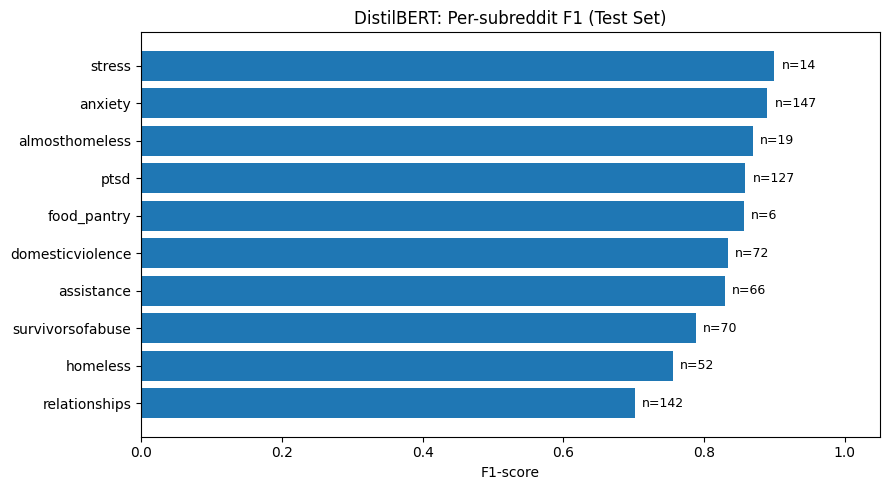

,subreddit,n,f1_med,f1_lo,f1_hi
7,relationships,142,0.705882,0.603448,0.786078
5,homeless,52,0.759310,0.599975,0.869565
9,survivorsofabuse,70,0.784810,0.646584,0.880000
2,assistance,66,0.833333,0.674390,0.942892
3,domesticviolence,72,0.835058,0.750000,0.910891
4,food_pantry,6,0.857143,0.447500,1.000000
6,ptsd,127,0.857143,0.794783,0.907741
0,almosthomeless,19,0.866667,0.695652,1.000000
1,anxiety,147,0.886425,0.839047,0.929574
8,stress,14,0.900000,0.725000,1.000000


In [27]:
sub_f1 = (
    bert_eval_df.groupby("subreddit")
    .apply(lambda g: f1_score(g["label"], g["pred"]))
    .reset_index(name="f1")
)

sub_n = bert_eval_df.groupby("subreddit").size().reset_index(name="n")

sub_perf = sub_f1.merge(sub_n, on="subreddit").sort_values("f1")
display(sub_perf)
sub_perf_sorted = sub_perf.sort_values("f1")

plt.figure(figsize=(9, 5))
plt.barh(sub_perf_sorted["subreddit"], sub_perf_sorted["f1"])
plt.xlabel("F1-score")
plt.title("DistilBERT: Per-subreddit F1 (Test Set)")
plt.xlim(0, 1.05)

# annotate n
for i, row in sub_perf_sorted.reset_index(drop=True).iterrows():
    plt.text(row["f1"] + 0.01, i, f'n={int(row["n"])}', va="center", fontsize=9)

plt.tight_layout()
plt.show()

def bootstrap_f1(y_true, y_pred, B=500, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        scores.append(f1_score(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 50, 97.5])

rows = []
for sub, g in bert_eval_df.groupby("subreddit"):
    ci = bootstrap_f1(g["label"].to_numpy(), g["pred"].to_numpy(), B=500)
    rows.append({"subreddit": sub, "n": len(g), "f1_med": ci[1], "f1_lo": ci[0], "f1_hi": ci[2]})

ci_df = pd.DataFrame(rows).sort_values("f1_med")
display(ci_df)

As seen from the diagram above, F1 score varies greatly by subreddit. The hardest community is relationships (n=142), with median F1 0.706 and a bootstrap 95% interval [0.603, 0.786]. This likely reflects that distress in relationship posts is often implicit and narrative-driven (e.g., recounting arguments, uncertainty, mixed emotions) rather than using explicit stress markers, which makes binary labels harder to infer from text alone. In contrast, clinical-leaning subreddits such as ptsd (n=127, F1=0.857 [0.795, 0.908]) and anxiety (n=147, F1≈0.886 [0.839, 0.930]) show consistently higher performance, plausibly because posts contain more direct symptom language and clearer self-disclosure of distress.

Some subreddits show wide uncertainty due to small sample sizes: almosthomeless (n=19) has F1=0.867 with a very wide interval [0.696, 1.000], and stress (n=14) has F1=0.900 with interval [0.725, 1.000], indicating that point estimates alone can be misleading. Overall, these results suggest the model may be learning a mix of general stress cues and community-specific phrasing, implying that real-world deployment should account for domain shift and subgroup reliability rather than relying on a single aggregate F1-score.

### Analysis 5: Threshold Analysis

Next, an analysis on the optimal threshold is done to understand the precision-recall tradeoff and determine the best threshold.

In [28]:
p_stress = bert_test_proba[:, 1] if "bert_test_proba" in globals() else (
    np.exp(bert_test_logits - np.max(bert_test_logits, axis=1, keepdims=True)) /
    np.exp(bert_test_logits - np.max(bert_test_logits, axis=1, keepdims=True)).sum(axis=1, keepdims=True)
)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []

for t in thresholds:
    pred_t = (p_stress >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "tn": tn,
    })

thr_df = pd.DataFrame(rows)
display(thr_df.round(4))

,threshold,precision,recall,f1,fp,fn,tp,tn
0,0.3,0.7626,0.9051,0.8278,104,35,334,242
1,0.4,0.7752,0.8970,0.8317,96,38,331,250
2,0.5,0.7770,0.8780,0.8244,93,45,324,253
3,0.6,0.7797,0.8537,0.8150,89,54,315,257
4,0.7,0.7880,0.8157,0.8016,81,68,301,265


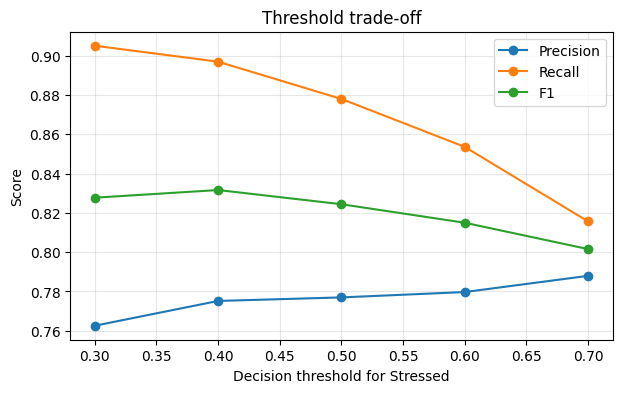

In [29]:
plt.figure(figsize=(7,4))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], marker="o", label="F1")
plt.xlabel("Decision threshold for Stressed")
plt.ylabel("Score")
plt.title("Threshold trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As the threshold increases:

- Precision increases from about 0.76 to 0.79 as decision threshold increases, meaning fewer false alarms.
- Recall decreases from about 0.91 to 0.81 as decision threshold increases, meaning more stressed posts are missed.
- F1 generally is higher at lower decision threshold and gradually declines at higher thresholds.

This confirms the expected trade-off: lower thresholds are safer for case-finding (higher recall), while higher thresholds reduce workload (higher precision).

For this model, it seems that the optimal threshold is at 0.40, where there is a higher F1. If the priority is to miss fewer stressed posts, a lower threshold (e.g.: 0.30) may be preferred; if the priority is reducing false alerts, a higher threshold (e.g.: 0.60) is more appropriate.

### Clinical Ethics and Deployment Risks

Although DistilBERT performs well on Dreaddit, deployment in mental-health contexts carries important ethical risks.

1. **False positives (over-flagging stress)**  
   In this project, false positives are slightly higher than false negatives. This can increase moderator workload and may unnecessarily escalate benign posts.

2. **False negatives (missed stress)**  
   Missed stressed posts may delay support for users who need help. Even with good overall F1, this risk remains clinically important.

3. **Privacy and surveillance concerns**  
   Automated monitoring of personal posts can feel intrusive, especially if users are unaware their text is being screened for mental-health signals.

4. **Stigma and misinterpretation risk**  
   Model outputs can be misunderstood as diagnosis. Stress labels are probabilistic signals from text, not clinical judgments.

5. **Domain and subgroup fairness risk**  
   Error rates vary across subreddits, suggesting uneven performance across communities and language styles.

#### Risk Mitigation for Real-World Use

- Use the model only for human-in-the-loop triage, not autonomous diagnosis or punishment.
- Present outputs as risk scores with uncertainty, not definitive labels.
- Calibrate decision threshold based on operational goals (e.g.: higher recall for safety-focused screening).
- Restrict data access, minimise retention, and communicate clearly how posts are used.
- Conduct periodic audits by subreddit/group to monitor drift and unequal error patterns.
- Define an escalation protocol: high-risk flags should route to trained moderators/support staff.

In summary, the model is best used as a supportive screening tool to prioritise attention, with strong governance and human oversight.

### Conclusion

While the fine-tuned transformer achieved the highest F1-score, performance varied significantly across subreddits, suggesting community-specific linguistic patterns.

Error analysis revealed that the model struggles with indirect or pragmatic expressions of stress, particularly in supportive or sarcastic contexts. Feature inspection shows heavy reliance on explicit stress-related vocabulary, indicating limitations in deeper contextual reasoning.

While such a system may support moderation workflows, it should not be deployed as an autonomous diagnostic tool. Risks of false negatives and domain shift must be carefully considered before real-world use.